## Установка библиотек и вывод датасета

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import Callback
df = pd.read_csv("filtered_thyroid_data.csv")
df_raw = df.copy()
df.head(5)

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


## Разведочный анализ данных: наполненность атрибутов и пропуски

In [17]:
print("Размер датасета (строки, столбцы):", df.shape)
print("\nОбщая информация о датасете:")
df.info()

print("\nКоличество пропущенных (пустых) значений по каждому атрибуту:")
print(df.isnull().sum())

empty_rows = df[df.isnull().any(axis=1)]
print(f"\nКоличество строк с хотя бы одним пропуском: {len(empty_rows)}")

duplicated_rows = df.duplicated().sum()
print(f"Количество полностью дублирующихся строк: {duplicated_rows}")


Размер датасета (строки, столбцы): (383, 13)

Общая информация о датасете:
<class 'pandas.DataFrame'>
RangeIndex: 383 entries, 0 to 382
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              383 non-null    int64
 1   Gender           383 non-null    str  
 2   Hx Radiothreapy  383 non-null    str  
 3   Adenopathy       383 non-null    str  
 4   Pathology        383 non-null    str  
 5   Focality         383 non-null    str  
 6   Risk             383 non-null    str  
 7   T                383 non-null    str  
 8   N                383 non-null    str  
 9   M                383 non-null    str  
 10  Stage            383 non-null    str  
 11  Response         383 non-null    str  
 12  Recurred         383 non-null    str  
dtypes: int64(1), str(12)
memory usage: 39.0 KB

Количество пропущенных (пустых) значений по каждому атрибуту:
Age                0
Gender             0
Hx Radiothreapy   

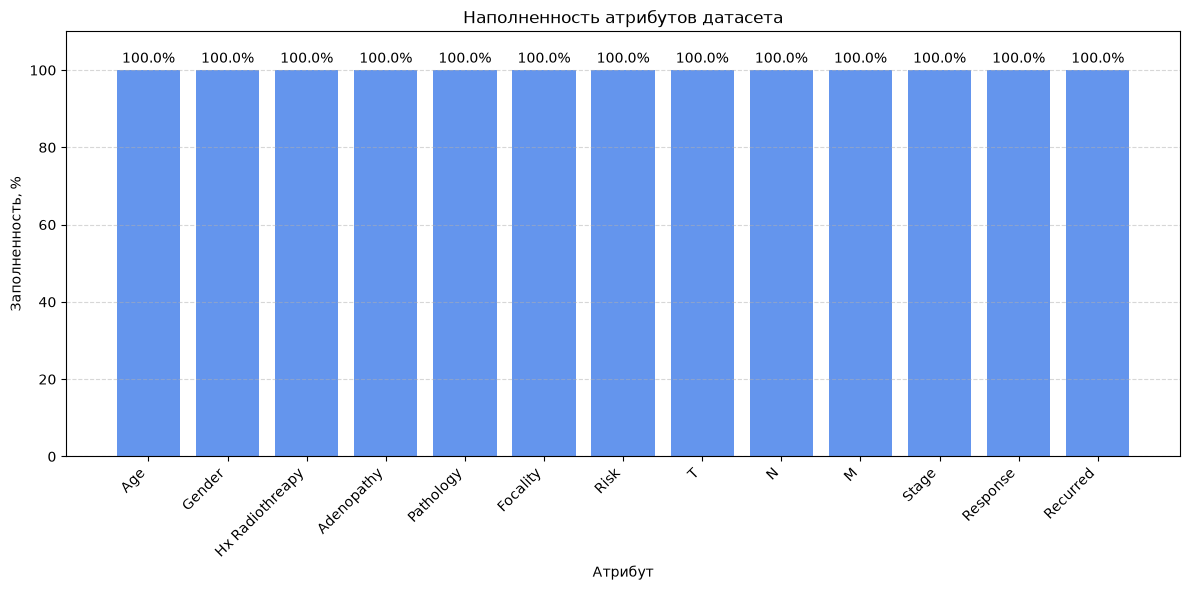

In [18]:
fill_counts = df.notnull().sum()
fill_percent = (fill_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(fill_counts.index, fill_percent.values, color='cornflowerblue')
ax.set_ylabel('Заполненность, %')
ax.set_xlabel('Атрибут')
ax.set_title('Наполненность атрибутов датасета')
ax.set_ylim(0, 110)
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, fill_percent.values):
    ax.annotate(f'{val}%', xy=(bar.get_x() + bar.get_width() / 2, val),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Замена категориальных данных на количественные

In [19]:
class RussianLogger(Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"Эпоха {epoch+1}: точность = {logs['accuracy']:.4f}, точность на валидации = {logs['val_accuracy']:.4f}")
categorical_cols = ['Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology',
                    'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
df['Recurred'] = df['Recurred'].map({'No': 0, 'Yes': 1})
df.head(5)

,Age,Gender,Hx Radiothreapy,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,0,0,3,2,1,2,0,0,0,0,2,0
1,34,0,0,3,2,1,2,0,0,0,0,1,0
2,30,0,0,3,2,1,2,0,0,0,0,1,0
3,62,0,0,3,2,1,2,0,0,0,0,1,0
4,62,0,0,3,2,0,2,0,0,0,0,1,0


### Матрица корреляции и влияние атрибутов на целевую переменную

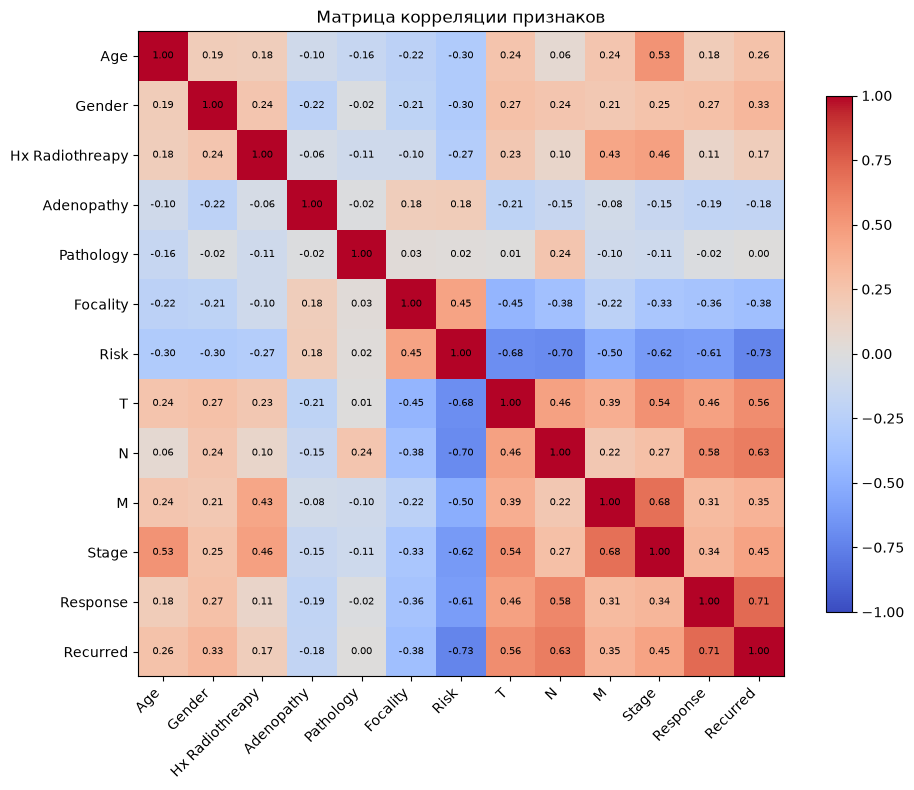

Корреляция признаков с целевой переменной Recurred (по убыванию силы влияния):
Risk              -0.733376
Response           0.708957
N                  0.632323
T                  0.556201
Stage              0.449137
Focality          -0.383776
M                  0.354360
Gender             0.328189
Age                0.258897
Adenopathy        -0.182530
Hx Radiothreapy    0.174407
Pathology          0.003272
Name: Recurred, dtype: float64


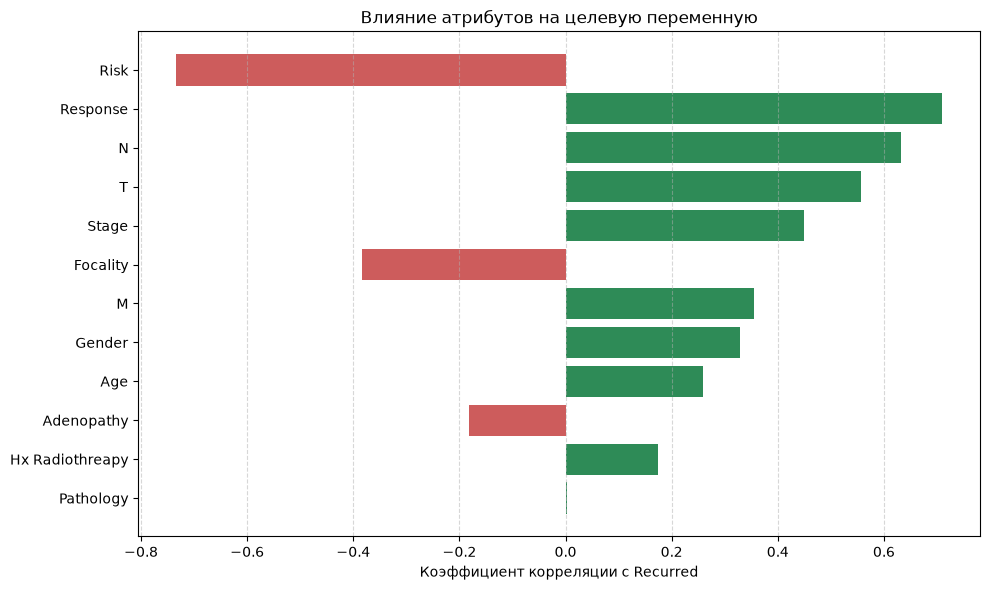

In [20]:
corr_matrix = df.corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.columns)
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('Матрица корреляции признаков')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

target_corr = corr_matrix['Recurred'].drop('Recurred').sort_values(key=abs, ascending=False)
print("Корреляция признаков с целевой переменной Recurred (по убыванию силы влияния):")
print(target_corr)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['indianred' if v < 0 else 'seagreen' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors)
ax.invert_yaxis()
ax.set_xlabel('Коэффициент корреляции с Recurred')
ax.set_title('Влияние атрибутов на целевую переменную')
ax.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Распределение датасета на обучащий и тестовый наборы

In [21]:
X = df.drop('Recurred', axis=1)
y = df['Recurred']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print("\nОбучающий набор данных (x_train):")
print(x_train.head(5))
print("\nЦелевая переменная обучающего набора (y_train):")
print(y_train.head(5))
print("\nТестовый набор данных (x_test):")
print(x_test.head(5))
print("\nЦелевая переменная тестового набора (y_test):")
print(y_test.head(5))


Обучающий набор данных (x_train):
     Age  Gender  Hx Radiothreapy  Adenopathy  Pathology  Focality  Risk  T  \
165   40       0                0           3          3         0     2  2   
321   62       0                0           5          3         0     1  3   
220   29       0                0           3          3         1     2  2   
94    37       0                0           3          1         0     2  2   
232   31       0                0           2          3         1     1  2   

     N  M  Stage  Response  
165  0  0      0         1  
321  2  0      1         3  
220  1  0      0         2  
94   0  0      0         1  
232  2  0      0         3  

Целевая переменная обучающего набора (y_train):
165    0
321    1
220    0
94     0
232    1
Name: Recurred, dtype: int64

Тестовый набор данных (x_test):
     Age  Gender  Hx Radiothreapy  Adenopathy  Pathology  Focality  Risk  T  \
268   32       0                0           3          3         1     2  3   
25

## Нормализация признаков

In [22]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index)
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=x_test.columns, index=x_test.index)
print(x_test_scaled[:5])
print(x_train_scaled[:5])

[[-0.60770939 -0.51933568 -0.14142136  0.05471183  0.4987207   0.77594732
   0.6979317   0.55453253 -0.66342407 -0.21063855 -0.32628    -0.63689373]
 [-0.7390828  -0.51933568 -0.14142136  1.72889391 -2.79498868  0.77594732
   0.6979317   0.55453253 -0.66342407 -0.21063855 -0.32628    -0.63689373]
 [-0.7390828  -0.51933568 -0.14142136 -2.45656128  0.4987207  -1.28874729
  -0.84965598  0.55453253  1.63044898 -0.21063855 -0.32628     1.51658121]
 [ 0.64033808 -0.51933568 -0.14142136  0.05471183 -2.79498868  0.77594732
  -0.84965598  0.55453253 -0.66342407 -0.21063855 -0.32628     1.51658121]
 [ 0.11484441 -0.51933568 -0.14142136  0.05471183  0.4987207   0.77594732
   0.6979317  -0.96732355 -0.66342407 -0.21063855 -0.32628    -0.63689373]]
[[-0.08221572 -0.51933568 -0.14142136  0.05471183  0.4987207  -1.28874729
   0.6979317  -0.20639551 -0.66342407 -0.21063855 -0.32628    -0.63689373]
 [ 1.36289187 -0.51933568 -0.14142136  1.72889391  0.4987207  -1.28874729
  -0.84965598  0.55453253  1.63

## Модель XGBoost

In [23]:
print("\n--- XGBoost ---")
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(x_train, y_train)
y_pred_xgb = xgb.predict(x_test)
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))


--- XGBoost ---
XGBoost Accuracy: 0.974025974025974
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        58
           1       0.95      0.95      0.95        19

    accuracy                           0.97        77
   macro avg       0.97      0.97      0.97        77
weighted avg       0.97      0.97      0.97        77



In [24]:
print("\n--- Подбор гиперпараметров XGBoost (GridSearchCV) ---")
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}
xgb_grid = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
xgb_grid.fit(x_train, y_train)
print("Лучшие параметры XGBoost:", xgb_grid.best_params_)
print("Лучшая точность на кросс-валидации:", round(xgb_grid.best_score_, 4))

xgb_best = xgb_grid.best_estimator_
y_pred_xgb_best = xgb_best.predict(x_test)
print("XGBoost (лучшие параметры) Accuracy на тесте:", accuracy_score(y_test, y_pred_xgb_best))
print(classification_report(y_test, y_pred_xgb_best))



--- Подбор гиперпараметров XGBoost (GridSearchCV) ---
Лучшие параметры XGBoost: {'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Лучшая точность на кросс-валидации: 0.9575
XGBoost (лучшие параметры) Accuracy на тесте: 0.987012987012987
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        58
           1       1.00      0.95      0.97        19

    accuracy                           0.99        77
   macro avg       0.99      0.97      0.98        77
weighted avg       0.99      0.99      0.99        77



## Модель Linear SVM

In [25]:
print("\n--- Linear SVM ---")
# LinearSVC чувствителен к масштабу признаков — используем стандартизированные данные,
# иначе метод может не сойтись (ConvergenceWarning) из-за разного масштаба атрибутов (например, Age)
linear_svc = LinearSVC(max_iter=20000, random_state=42)
linear_svc.fit(x_train_scaled_df, y_train)
y_pred_lsvc = linear_svc.predict(x_test_scaled_df)
print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_lsvc))
print(classification_report(y_test, y_pred_lsvc))


--- Linear SVM ---
Linear SVM Accuracy: 0.922077922077922
              precision    recall  f1-score   support

           0       0.93      0.97      0.95        58
           1       0.88      0.79      0.83        19

    accuracy                           0.92        77
   macro avg       0.91      0.88      0.89        77
weighted avg       0.92      0.92      0.92        77



In [26]:
print("\n--- Подбор гиперпараметров Linear SVM (GridSearchCV) ---")
lsvc_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge']
}
lsvc_grid = GridSearchCV(
    LinearSVC(max_iter=20000, random_state=42),
    param_grid=lsvc_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
lsvc_grid.fit(x_train_scaled_df, y_train)
print("Лучшие параметры Linear SVM:", lsvc_grid.best_params_)
print("Лучшая точность на кросс-валидации:", round(lsvc_grid.best_score_, 4))

lsvc_best = lsvc_grid.best_estimator_
y_pred_lsvc_best = lsvc_best.predict(x_test_scaled_df)
print("Linear SVM (лучшие параметры) Accuracy на тесте:", accuracy_score(y_test, y_pred_lsvc_best))
print(classification_report(y_test, y_pred_lsvc_best))



--- Подбор гиперпараметров Linear SVM (GridSearchCV) ---
Лучшие параметры Linear SVM: {'C': 100, 'loss': 'hinge'}
Лучшая точность на кросс-валидации: 0.9053
Linear SVM (лучшие параметры) Accuracy на тесте: 0.974025974025974
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        58
           1       1.00      0.89      0.94        19

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.96        77
weighted avg       0.97      0.97      0.97        77



## Модель Random Forest

In [27]:
print("\n--- Random Forest ---")
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


--- Random Forest ---
Random Forest Accuracy: 0.974025974025974
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        58
           1       1.00      0.89      0.94        19

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.96        77
weighted avg       0.97      0.97      0.97        77



In [28]:
print("\n--- Подбор гиперпараметров Random Forest (GridSearchCV) ---")
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
rf_grid.fit(x_train, y_train)
print("Лучшие параметры Random Forest:", rf_grid.best_params_)
print("Лучшая точность на кросс-валидации:", round(rf_grid.best_score_, 4))

rf_best = rf_grid.best_estimator_
y_pred_rf_best = rf_best.predict(x_test)
print("Random Forest (лучшие параметры) Accuracy на тесте:", accuracy_score(y_test, y_pred_rf_best))
print(classification_report(y_test, y_pred_rf_best))



--- Подбор гиперпараметров Random Forest (GridSearchCV) ---
Лучшие параметры Random Forest: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Лучшая точность на кросс-валидации: 0.951
Random Forest (лучшие параметры) Accuracy на тесте: 0.961038961038961
              precision    recall  f1-score   support

           0       0.97      0.98      0.97        58
           1       0.94      0.89      0.92        19

    accuracy                           0.96        77
   macro avg       0.96      0.94      0.95        77
weighted avg       0.96      0.96      0.96        77



## Визуализация сравнения моделей

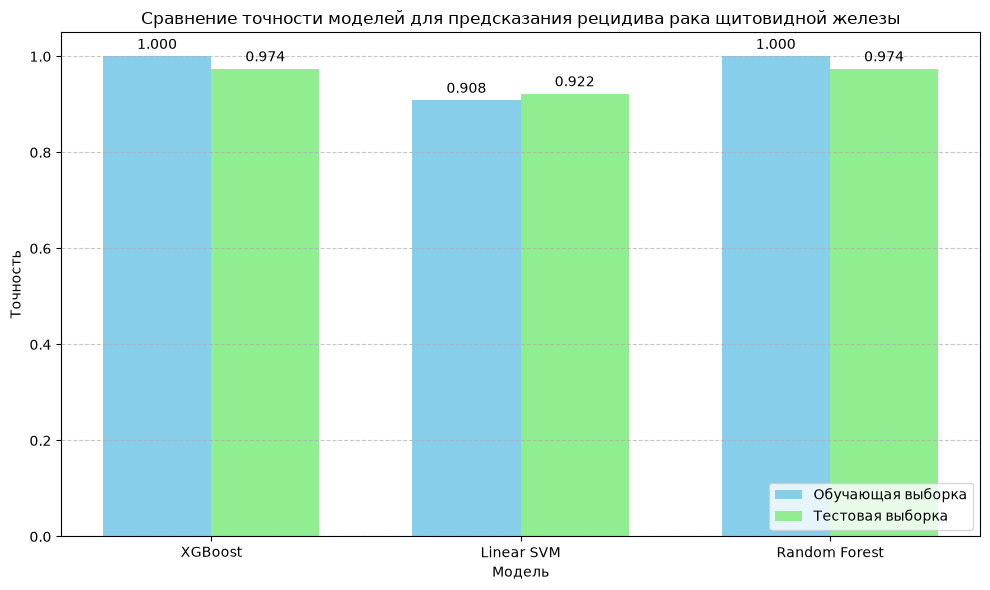

In [30]:
models = ['XGBoost', 'Linear SVM', 'Random Forest']
model_data = {
    'XGBoost': {'model': xgb, 'x_train': x_train, 'y_pred': y_pred_xgb},
    'Linear SVM': {'model': linear_svc, 'x_train': x_train_scaled_df, 'y_pred': y_pred_lsvc},
    'Random Forest': {'model': rf, 'x_train': x_train, 'y_pred': y_pred_rf},
}

train_acc = [model_data[m]['model'].score(model_data[m]['x_train'], y_train) for m in models]
test_acc = [accuracy_score(y_test, model_data[m]['y_pred']) for m in models]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, train_acc, width, label='Обучающая выборка', color='skyblue')
rects2 = ax.bar(x + width/2, test_acc, width, label='Тестовая выборка', color='lightgreen')
ax.set_ylabel('Точность')
ax.set_xlabel('Модель')
ax.set_title('Сравнение точности моделей для предсказания рецидива рака щитовидной железы')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
plt.tight_layout()
plt.show()


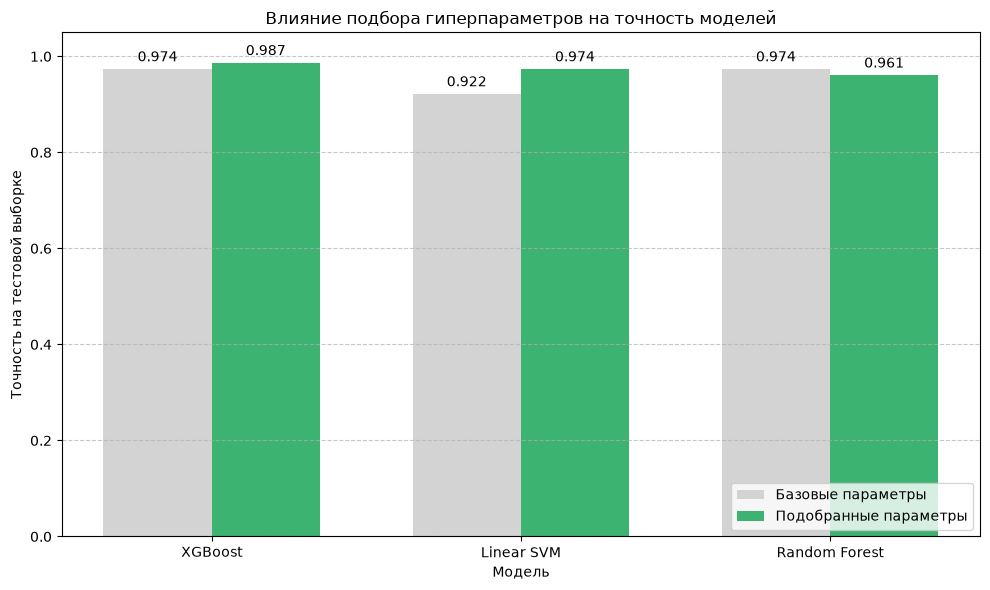

In [31]:
tuned_test_acc = [
    accuracy_score(y_test, y_pred_xgb_best),
    accuracy_score(y_test, y_pred_lsvc_best),
    accuracy_score(y_test, y_pred_rf_best)
]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, test_acc, width, label='Базовые параметры', color='lightgray')
rects2 = ax.bar(x + width/2, tuned_test_acc, width, label='Подобранные параметры', color='mediumseagreen')
ax.set_ylabel('Точность на тестовой выборке')
ax.set_xlabel('Модель')
ax.set_title('Влияние подбора гиперпараметров на точность моделей')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
autolabel(rects1)
autolabel(rects2)
plt.tight_layout()
plt.show()


## Изменение структуры набора данных

Вносим следующие изменения в структуру данных:

1. **Возраст переводится в категориальный признак** `Age_Group` (возрастные группы вместо непрерывного числа) — убираем исходный столбец `Age`.
2. **Убираем столбцы `T`, `N`, `M`** — они детализируют стадию заболевания, информация о которой в основном уже содержится в столбце `Stage` (проверено матрицей корреляции); это снижает мультиколлинеарность и размерность признакового пространства.
3. **One-Hot Encoding** применяется к номинальным категориальным признакам без естественного порядка (`Gender`, `Hx Radiothreapy`, `Adenopathy`, `Pathology`, `Focality`, `Age_Group`) вместо `LabelEncoder`, чтобы не задавать модели ложный порядок между категориями.
4. Для признаков с естественным порядком (`Risk`, `Response`, `Stage`) сохраняется порядковое (ordinal) кодирование.

In [32]:
df2 = df_raw.copy()

# 1. Возрастные группы вместо непрерывного возраста
df2['Age_Group'] = pd.cut(
    df2['Age'],
    bins=[0, 30, 45, 60, 100],
    labels=['<=30', '31-45', '46-60', '60+']
)
df2 = df2.drop(columns=['Age'])

# 2. Убираем детализирующие TNM-признаки, оставляя агрегированную стадию Stage
df2 = df2.drop(columns=['T', 'N', 'M'])

# 3. Целевая переменная в числовой формат
df2['Recurred'] = df2['Recurred'].map({'No': 0, 'Yes': 1})

# 4. One-Hot Encoding для номинальных признаков без естественного порядка
nominal_cols = ['Gender', 'Hx Radiothreapy', 'Adenopathy', 'Pathology', 'Focality', 'Age_Group']
df2 = pd.get_dummies(df2, columns=nominal_cols, drop_first=True)

# 5. Порядковое кодирование признаков с естественным порядком
ordinal_maps = {
    'Risk': {'Low': 0, 'Intermediate': 1, 'High': 2},
    'Response': {'Excellent': 0, 'Indeterminate': 1, 'Biochemical Incomplete': 2, 'Structural Incomplete': 3},
    'Stage': {'I': 0, 'II': 1, 'III': 2, 'IVA': 3, 'IVB': 4}
}
for col, mapping in ordinal_maps.items():
    df2[col] = df2[col].map(mapping)

print("Новая структура датасета:")
print(df2.head(5))
print("\nСтолбцы:", list(df2.columns))
print("Количество признаков:", df2.shape[1] - 1, "(было", df.shape[1] - 1, ")")


Новая структура датасета:
   Risk  Stage  Response  Recurred  Gender_M  Hx Radiothreapy_Yes  \
0     0      0         1         0     False                False   
1     0      0         0         0     False                False   
2     0      0         0         0     False                False   
3     0      0         0         0     False                False   
4     0      0         0         0     False                False   

   Adenopathy_Extensive  Adenopathy_Left  Adenopathy_No  Adenopathy_Posterior  \
0                 False            False           True                 False   
1                 False            False           True                 False   
2                 False            False           True                 False   
3                 False            False           True                 False   
4                 False            False           True                 False   

   Adenopathy_Right  Pathology_Hurthel cell  Pathology_Micropapillary  \

In [33]:
X2 = df2.drop('Recurred', axis=1)
y2 = df2['Recurred']
x_train2, x_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.20, random_state=42)
print("Размер новой обучающей выборки:", x_train2.shape)
print("Размер новой тестовой выборки:", x_test2.shape)


Размер новой обучающей выборки: (306, 17)
Размер новой тестовой выборки: (77, 17)


In [34]:
scaler2 = StandardScaler()
x_train2_scaled = scaler2.fit_transform(x_train2)
x_test2_scaled = scaler2.transform(x_test2)
print(x_train2_scaled[:5])
print(x_test2_scaled[:5])


[[-0.6979317  -0.32628    -0.82480947 -0.51933568 -0.14142136 -0.14142136
  -0.21896394  0.64042037 -0.08111071 -0.3933408  -0.24253563 -0.34767675
   0.56477032 -1.28874729  1.2798168  -0.49897855 -0.39886202]
 [ 0.84965598  1.04141424  1.57131425 -0.51933568 -0.14142136 -0.14142136
  -0.21896394 -1.56147438 -0.08111071  2.54232465 -0.24253563 -0.34767675
   0.56477032 -1.28874729 -0.78136183 -0.49897855  2.50713268]
 [-0.6979317  -0.32628    -0.02610157 -0.51933568 -0.14142136 -0.14142136
  -0.21896394  0.64042037 -0.08111071 -0.3933408  -0.24253563 -0.34767675
   0.56477032  0.77594732 -0.78136183 -0.49897855 -0.39886202]
 [-0.6979317  -0.32628    -0.82480947 -0.51933568 -0.14142136 -0.14142136
  -0.21896394  0.64042037 -0.08111071 -0.3933408   4.12310563 -0.34767675
  -1.77063128 -1.28874729  1.2798168  -0.49897855 -0.39886202]
 [ 0.84965598 -0.32628     1.57131425 -0.51933568 -0.14142136 -0.14142136
   4.5669621  -1.56147438 -0.08111071 -0.3933408  -0.24253563 -0.34767675
   0.564

### Обучение моделей на изменённой структуре данных с подбором параметров

In [35]:
print("--- XGBoost на новой структуре данных ---")
xgb_grid2 = GridSearchCV(
    XGBClassifier(eval_metric='logloss', random_state=42),
    param_grid=xgb_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)
xgb_grid2.fit(x_train2, y_train2)
xgb_best2 = xgb_grid2.best_estimator_
y_pred_xgb2 = xgb_best2.predict(x_test2)
print("Лучшие параметры:", xgb_grid2.best_params_)
print("XGBoost Accuracy (новая структура):", accuracy_score(y_test2, y_pred_xgb2))
print(classification_report(y_test2, y_pred_xgb2))

print("\n--- Linear SVM на новой структуре данных ---")
lsvc_grid2 = GridSearchCV(
    LinearSVC(max_iter=20000, random_state=42),
    param_grid=lsvc_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)
lsvc_grid2.fit(x_train2_scaled, y_train2)
lsvc_best2 = lsvc_grid2.best_estimator_
y_pred_lsvc2 = lsvc_best2.predict(x_test2_scaled)
print("Лучшие параметры:", lsvc_grid2.best_params_)
print("Linear SVM Accuracy (новая структура):", accuracy_score(y_test2, y_pred_lsvc2))
print(classification_report(y_test2, y_pred_lsvc2))

print("\n--- Random Forest на новой структуре данных ---")
rf_grid2 = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5, scoring='accuracy', n_jobs=-1
)
rf_grid2.fit(x_train2, y_train2)
rf_best2 = rf_grid2.best_estimator_
y_pred_rf2 = rf_best2.predict(x_test2)
print("Лучшие параметры:", rf_grid2.best_params_)
print("Random Forest Accuracy (новая структура):", accuracy_score(y_test2, y_pred_rf2))
print(classification_report(y_test2, y_pred_rf2))


--- XGBoost на новой структуре данных ---
Лучшие параметры: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 1.0}
XGBoost Accuracy (новая структура): 0.974025974025974
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        58
           1       1.00      0.89      0.94        19

    accuracy                           0.97        77
   macro avg       0.98      0.95      0.96        77
weighted avg       0.97      0.97      0.97        77


--- Linear SVM на новой структуре данных ---
Лучшие параметры: {'C': 0.1, 'loss': 'squared_hinge'}
Linear SVM Accuracy (новая структура): 0.987012987012987
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        58
           1       1.00      0.95      0.97        19

    accuracy                           0.99        77
   macro avg       0.99      0.97      0.98        77
weighted avg       0.99      0.99      0.99        

## Оценка влияния изменения структуры данных на результат обучения

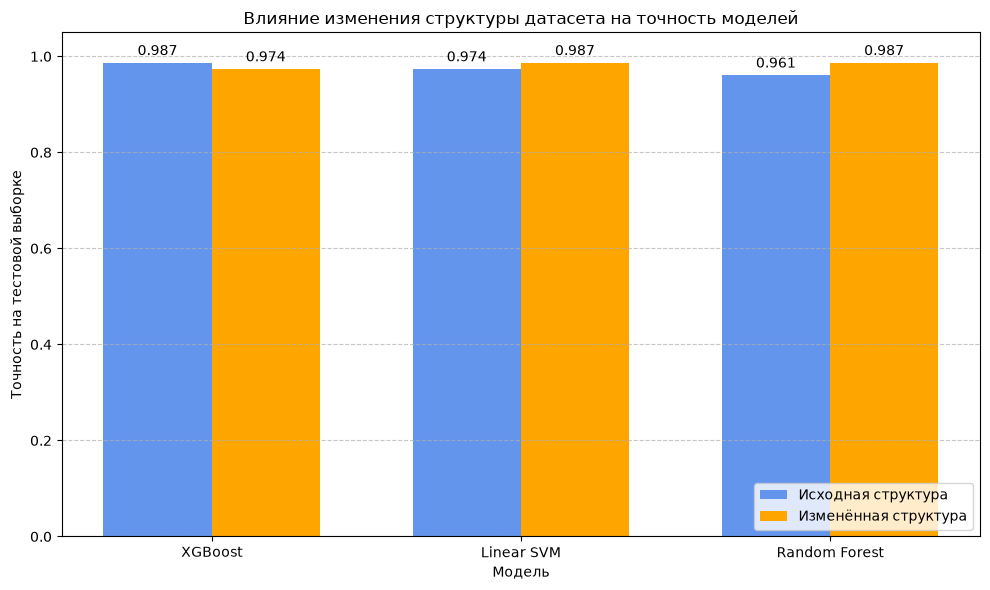

XGBoost: исходная структура = 0.9870, новая структура = 0.9740 (-0.0130)
Linear SVM: исходная структура = 0.9740, новая структура = 0.9870 (+0.0130)
Random Forest: исходная структура = 0.9610, новая структура = 0.9870 (+0.0260)


In [36]:
original_struct_acc = [
    accuracy_score(y_test, y_pred_xgb_best),
    accuracy_score(y_test, y_pred_lsvc_best),
    accuracy_score(y_test, y_pred_rf_best)
]
new_struct_acc = [
    accuracy_score(y_test2, y_pred_xgb2),
    accuracy_score(y_test2, y_pred_lsvc2),
    accuracy_score(y_test2, y_pred_rf2)
]

x = np.arange(len(models))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, original_struct_acc, width, label='Исходная структура', color='cornflowerblue')
rects2 = ax.bar(x + width/2, new_struct_acc, width, label='Изменённая структура', color='orange')
ax.set_ylabel('Точность на тестовой выборке')
ax.set_xlabel('Модель')
ax.set_title('Влияние изменения структуры датасета на точность моделей')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
autolabel(rects1)
autolabel(rects2)
plt.tight_layout()
plt.show()

for m, orig, new in zip(models, original_struct_acc, new_struct_acc):
    diff = new - orig
    sign = '+' if diff >= 0 else ''
    print(f"{m}: исходная структура = {orig:.4f}, новая структура = {new:.4f} ({sign}{diff:.4f})")


## Выбор наиболее эффективной модели

In [37]:
summary_rows = []
for m, acc in zip(models, test_acc):
    summary_rows.append({'Модель': m, 'Вариант': 'Базовые параметры / исходная структура', 'Точность': acc})
for m, acc in zip(models, original_struct_acc):
    summary_rows.append({'Модель': m, 'Вариант': 'Подобранные параметры / исходная структура', 'Точность': acc})
for m, acc in zip(models, new_struct_acc):
    summary_rows.append({'Модель': m, 'Вариант': 'Подобранные параметры / новая структура', 'Точность': acc})

results_df = pd.DataFrame(summary_rows).sort_values('Точность', ascending=False).reset_index(drop=True)
print(results_df)

best_row = results_df.iloc[0]
print(f"\nНаиболее эффективная модель: {best_row['Модель']} ({best_row['Вариант']}) "
      f"с точностью {best_row['Точность']:.4f}")


          Модель                                     Вариант  Точность
0        XGBoost  Подобранные параметры / исходная структура  0.987013
1     Linear SVM     Подобранные параметры / новая структура  0.987013
2  Random Forest     Подобранные параметры / новая структура  0.987013
3        XGBoost      Базовые параметры / исходная структура  0.974026
4  Random Forest      Базовые параметры / исходная структура  0.974026
5        XGBoost     Подобранные параметры / новая структура  0.974026
6     Linear SVM  Подобранные параметры / исходная структура  0.974026
7  Random Forest  Подобранные параметры / исходная структура  0.961039
8     Linear SVM      Базовые параметры / исходная структура  0.922078

Наиболее эффективная модель: XGBoost (Подобранные параметры / исходная структура) с точностью 0.9870
